Simulate a real-time data stream (e.g., sensor readings or network traffic values) and develop a simple stream mining model that continuously analyzes incoming data to detect significant patterns or anomalies.

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Parameters

WINDOW_SIZE = 5
THRESHOLD = 8

window = []

readings = []
status_list = []

In [3]:
# Real-time stream simulation

for _ in range(30):

    temp = random.randint(25, 30)

    if random.random() < 0.1:
        temp += random.randint(10, 20)

    if len(window) >= WINDOW_SIZE:

        avg = sum(window) / WINDOW_SIZE

        if abs(temp - avg) > THRESHOLD:
            status = "Anomaly"
        else:
            status = "Normal"

    else:
        status = "Collecting"

    print(f"Temp = {temp} -> {status}")

    readings.append(temp)
    status_list.append(status)

    window.append(temp)

    if len(window) > WINDOW_SIZE:
        window.pop(0)

    time.sleep(1)

Temp = 30 -> Collecting
Temp = 29 -> Collecting
Temp = 29 -> Collecting
Temp = 25 -> Collecting
Temp = 29 -> Collecting
Temp = 28 -> Normal
Temp = 25 -> Normal
Temp = 30 -> Normal
Temp = 25 -> Normal
Temp = 26 -> Normal
Temp = 36 -> Anomaly
Temp = 26 -> Normal
Temp = 27 -> Normal
Temp = 29 -> Normal
Temp = 30 -> Normal
Temp = 30 -> Normal
Temp = 29 -> Normal
Temp = 48 -> Anomaly
Temp = 27 -> Normal
Temp = 26 -> Normal
Temp = 26 -> Normal
Temp = 28 -> Normal
Temp = 30 -> Normal
Temp = 30 -> Normal
Temp = 25 -> Normal
Temp = 27 -> Normal
Temp = 30 -> Normal
Temp = 25 -> Normal
Temp = 26 -> Normal
Temp = 28 -> Normal


In [4]:
# Observation table

df = pd.DataFrame({
    "Temperature": readings,
    "Status": status_list
})

print(df)

    Temperature      Status
0            30  Collecting
1            29  Collecting
2            29  Collecting
3            25  Collecting
4            29  Collecting
5            28      Normal
6            25      Normal
7            30      Normal
8            25      Normal
9            26      Normal
10           36     Anomaly
11           26      Normal
12           27      Normal
13           29      Normal
14           30      Normal
15           30      Normal
16           29      Normal
17           48     Anomaly
18           27      Normal
19           26      Normal
20           26      Normal
21           28      Normal
22           30      Normal
23           30      Normal
24           25      Normal
25           27      Normal
26           30      Normal
27           25      Normal
28           26      Normal
29           28      Normal


In [5]:
# Display anomalies

anomalies = df[df["Status"] == "Anomaly"]

print(anomalies)

    Temperature   Status
10           36  Anomaly
17           48  Anomaly


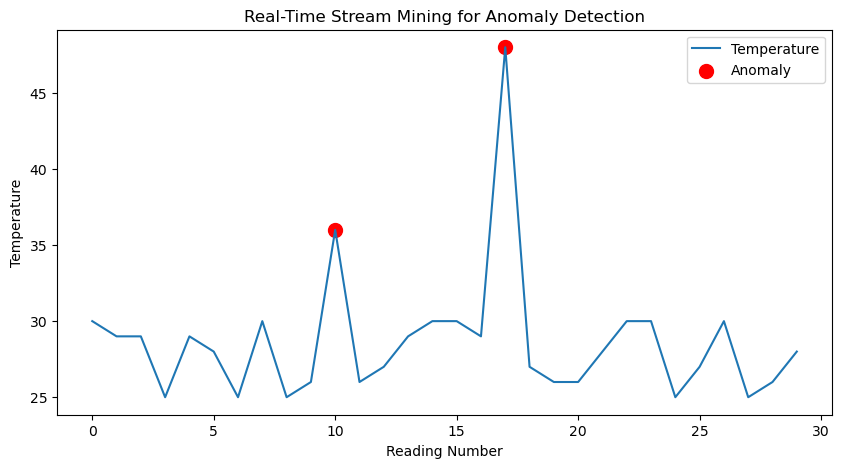

In [6]:
# Visualization

normal_x = []
normal_y = []

anomaly_x = []
anomaly_y = []

for i in range(len(readings)):

    if status_list[i] == "Anomaly":
        anomaly_x.append(i)
        anomaly_y.append(readings[i])
    else:
        normal_x.append(i)
        normal_y.append(readings[i])

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(readings)),
    readings,
    label="Temperature"
)

plt.scatter(
    anomaly_x,
    anomaly_y,
    s=100,
    color="red",
    label="Anomaly"
)

plt.xlabel("Reading Number")
plt.ylabel("Temperature")

plt.title("Real-Time Stream Mining for Anomaly Detection")

plt.legend()

plt.show()

In [7]:
# Summary

print("Average Temperature =", round(df["Temperature"].mean(), 2))
print("Maximum Temperature =", df["Temperature"].max())
print("Minimum Temperature =", df["Temperature"].min())
print("Total Anomalies =", len(anomalies))

Average Temperature = 28.63
Maximum Temperature = 48
Minimum Temperature = 25
Total Anomalies = 2
